Parameter Estimation of a Multinomial Distribution using Maximum Likelihood Estimation (MLE) and Maximum A Posteriori (MAP) on the 20 Newsgroups Dataset

##Aim

To estimate the parameters of a multinomial distribution using Maximum Likelihood Estimation (MLE) and Maximum A Posteriori (MAP) on the 20 Newsgroups dataset, and to compare the effect of different Dirichlet priors on the estimated probabilities.

##Objective
To load and preprocess the 20 Newsgroups dataset.
To estimate multinomial parameters using MLE.
To estimate multinomial parameters using MAP with different Dirichlet priors.
To compare the estimated probabilities obtained using MLE and MAP.
To analyze the influence of prior distributions on parameter estimation.

##Theory

Maximum Likelihood Estimation (MLE) estimates the parameters that maximize the likelihood of the observed data. For a multinomial distribution, MLE estimates the probability of each category as the ratio of its count to the total number of observations.

Maximum A Posteriori (MAP) estimation extends MLE by incorporating prior knowledge through a prior probability distribution. For multinomial distributions, the Dirichlet distribution is commonly used as the prior because it is conjugate to the multinomial distribution. Different values of the Dirichlet prior (α) influence the estimated probabilities by introducing smoothing, reducing the effect of sparse observations, and preventing zero probabilities.

#Import Libraries


In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer

import matplotlib.pyplot as plt

#Load and Preprocess Dataset

In [2]:
# Load a subset of the 20 Newsgroups dataset
categories = [
    'sci.space',
    'comp.graphics',
    'rec.sport.baseball'
]

dataset = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes')
)

# Convert text into word count vectors
vectorizer = CountVectorizer(
    stop_words='english',
    max_features=1000
)

X = vectorizer.fit_transform(dataset.data)

print("Documents :", X.shape[0])
print("Vocabulary:", X.shape[1])

Documents : 1774
Vocabulary: 1000


#MLE Estimation

In [3]:
word_counts = np.asarray(X.sum(axis=0)).flatten()

theta_mle = word_counts / word_counts.sum()

print("First 10 MLE probabilities")
print(theta_mle[:10])

print("\nSum =", theta_mle.sum())

First 10 MLE probabilities
[0.00300413 0.00219185 0.00176637 0.00180505 0.00174059 0.00149562
 0.00092831 0.00055441 0.00354564 0.00150851]

Sum = 1.0


#MAP Estimation using Dirichlet Prior

In [4]:
def map_estimate(counts, alpha):

    K = len(counts)

    numerator = counts + alpha - 1
    denominator = counts.sum() + K * (alpha - 1)

    return numerator / denominator

#Apply Different Priors

In [5]:
alphas = [1, 2, 5, 10]

results = {}

for a in alphas:
    results[a] = map_estimate(word_counts, a)

for a in alphas:
    print(f"\nAlpha = {a}")
    print(results[a][:10])


Alpha = 1
[0.00300413 0.00219185 0.00176637 0.00180505 0.00174059 0.00149562
 0.00092831 0.00055441 0.00354564 0.00150851]

Alpha = 2
[0.00297862 0.00217668 0.00175662 0.00179481 0.00173116 0.00148931
 0.00092923 0.00056008 0.00351324 0.00150204]

Alpha = 5
[0.00290584 0.0021334  0.00172879 0.00176557 0.00170427 0.00147131
 0.00093183 0.00057626 0.00342079 0.00148357]

Alpha = 10
[0.00279575 0.00206793 0.00168669 0.00172135 0.00166359 0.00144409
 0.00093577 0.00060074 0.00328096 0.00145564]


#compare MLE and MAP

In [6]:
comparison = pd.DataFrame({
    "MLE": theta_mle[:20],
    "MAP alpha=2": results[2][:20],
    "MAP alpha=5": results[5][:20],
    "MAP alpha=10": results[10][:20]
})

comparison

,MLE,MAP alpha=2,MAP alpha=5,MAP alpha=10
0,0.003004,0.002979,0.002906,0.002796
1,0.002192,0.002177,0.002133,0.002068
2,0.001766,0.001757,0.001729,0.001687
3,0.001805,0.001795,0.001766,0.001721
4,0.001741,0.001731,0.001704,0.001664
5,0.001496,0.001489,0.001471,0.001444
6,0.000928,0.000929,0.000932,0.000936
7,0.000554,0.000560,0.000576,0.000601
8,0.003546,0.003513,0.003421,0.003281
9,0.001509,0.001502,0.001484,0.001456


#Visualization

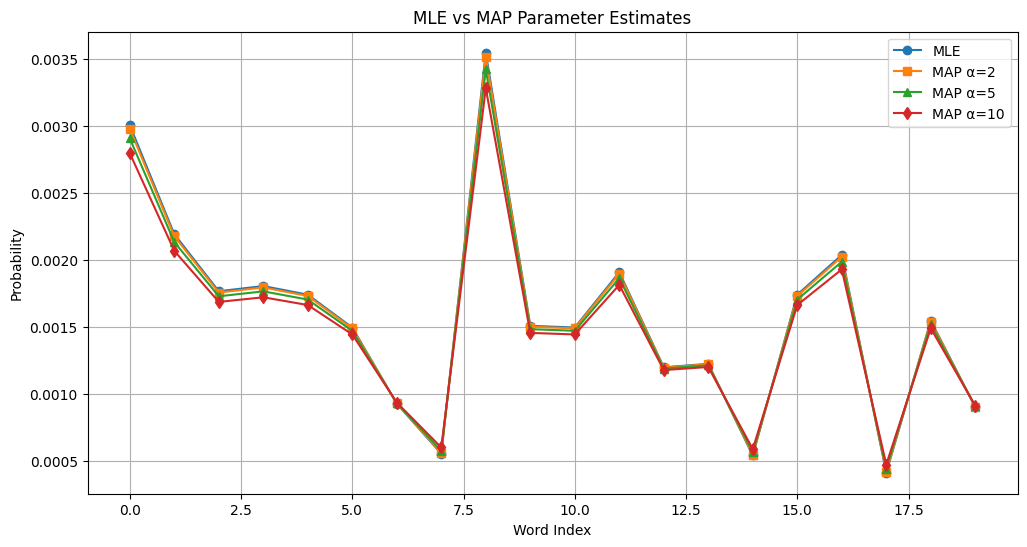

In [7]:
indices = np.arange(20)

plt.figure(figsize=(12,6))

plt.plot(indices, theta_mle[:20], marker='o', label='MLE')
plt.plot(indices, results[2][:20], marker='s', label='MAP α=2')
plt.plot(indices, results[5][:20], marker='^', label='MAP α=5')
plt.plot(indices, results[10][:20], marker='d', label='MAP α=10')

plt.xlabel("Word Index")
plt.ylabel("Probability")
plt.title("MLE vs MAP Parameter Estimates")
plt.legend()
plt.grid(True)

plt.show()

## Result & Conclusion

- Successfully estimated the parameters of the multinomial distribution using **Maximum Likelihood Estimation (MLE)** and **Maximum A Posteriori (MAP)**.
- **MLE** estimated the parameters using only the observed word frequencies from the dataset.
- **MAP** incorporated a **Dirichlet prior**, resulting in smoother probability estimates.
- Increasing the value of the **Dirichlet prior (α)** produced more uniform probability distributions.
- MAP reduced the occurrence of zero probabilities, making it more suitable for sparse text data.
- The experiment demonstrated that **MAP provides more robust parameter estimation than MLE** when prior knowledge is available.